# ============================================================
# TRADECLEANSE — NOTEBOOK 02 : Pipeline de Nettoyage Complet
# DCLE821 — QuantAxis Capital
# Etudiant(s) : ___________________________________
# Date        : ___________________________________
# ============================================================

In [8]:

#
# CONTRAINTES OBLIGATOIRES :
#   - Ne jamais modifier tradecleanse_raw.csv
#   - Toujours travailler sur une copie : df = pd.read_csv(...).copy()
#   - Chaque etape doit etre loggee : nb lignes avant / apres / supprimees
#   - Chaque decision doit etre justifiee en commentaire (raison METIER)
#   - Le dataset final doit etre sauvegarde dans : tradecleanse_clean.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import os
import warnings
warnings.filterwarnings('ignore')

# Configuration du logging (ne pas modifier)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[
        logging.FileHandler('tradecleanse_pipeline.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# ============================================================
# CHARGEMENT (ne pas modifier)
# ============================================================
df_raw = pd.read_csv('data/tradecleanse_raw.csv', low_memory=False)
df = df_raw.copy()
logger.info(f"Dataset charge : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# ============================================================
# ETAPE 1 — Remplacement des valeurs sentinelles
# ============================================================
# CONSIGNE :
# Identifiez et remplacez TOUTES les valeurs sentinelles par NaN.
# Une sentinelle est une valeur utilisee a la place d'un NaN reel :
# textuelles (#N/A, N/A, #VALUE!, -, nd, null...) ET numeriques
# (ex: 99999 utilise comme code "donnee manquante" sur country_risk).
#
# ATTENTION : certaines colonnes sont en type "object" a cause des
# sentinelles textuelles melangees a des valeurs numeriques.
# Pensez a gerer le cast des colonnes apres nettoyage.
#
# Loggez le nb de NaN total avant et apres.

before = len(df)
# --- Votre code ici ---
logger.info(f"[Sentinelles] {before} -> {len(df)} lignes")
nan_before = df.isna().sum().sum()
logger.info(f"[Sentinelles] NaN avant : {nan_before:,}")
# sentinelles textuelles — toutes colonnes object
# Raison métier : les exports Bloomberg/Murex/Refinitiv produisent des marqueurs
# de données absentes non-standard qui bloquent le cast numérique ultérieur.
# On les unifie tous en NaN avant tout traitement.
TEXT_SENTINELS = {
    "N/A", "n/a", "NA", "na",
    "#N/A", "#N/A N/A", "#VALUE!", "#REF!", "#DIV/0!",
    "#NUM!", "#NAME?", "#NULL!",
    "-", "--", "---",
    "NULL", "null", "Null",
    "NaN", "nan", "NAN",
    "nd", "ND", "n.d.", "N.D.",
    "none", "None", "NONE",
    "?", "unknown", "UNKNOWN",
    "", " ",
}

# Application sur toutes les colonnes object/string uniquement
# (pas de risque d'écraser des valeurs légitimes dans les colonnes numériques)
obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

n_replaced_text = 0
for col in obj_cols:
    mask = df[col].isin(TEXT_SENTINELS)
    n_replaced_text += mask.sum()
    df.loc[mask, col] = np.nan

logger.info(f"[Sentinelles textuelles] {n_replaced_text:,} valeurs remplacées par NaN dans {len(obj_cols)} colonnes")
# sentinelles numériques — colonnes spécifiques
# Raison métier : certaines valeurs numériques hors-domaine sont des codes
# de données manquantes introduits par les systèmes sources :
#
#   country_risk  : score attendu [0, 100] → 99999 / -1 / 999 = sentinelle
#   volatility_30d: volatilité attendue (0, 200] → 9999 / -999 = sentinelle
#   notional_eur  : expositions réelles > 0 → 0.0 exact = champ non renseigné
#   price / bid / ask : prix de marché > 0 → 0.0 exact = donnée absente
#   quantity      : entier > 0 → -9999 / 99999999 = code erreur Murex connu
#   default_flag  : binaire {0,1} → toute autre valeur entière = sentinelle

NUMERIC_SENTINELS: dict[str, list] = {
    "country_risk"  : [99999, -1, 999, -999],
    "volatility_30d": [9999, -999, -9999, 99999],
    "notional_eur"  : [0.0],        # 0 notionnel = champ vide, pas une position
    "price"         : [0.0],
    "bid"           : [0.0],
    "ask"           : [0.0],
    "quantity"      : [-9999, 99999999],
}

n_replaced_num = 0
for col, sentinel_vals in NUMERIC_SENTINELS.items():
    if col not in df.columns:
        continue
    # Cast préalable en numérique pour comparer des floats correctement
    df[col] = pd.to_numeric(df[col], errors="coerce")
    mask = df[col].isin(sentinel_vals)
    n_replaced_num += mask.sum()
    df.loc[mask, col] = np.nan
    logger.info(f"  [{col}] {mask.sum()} sentinelles numériques → NaN")

logger.info(f"[Sentinelles numériques] {n_replaced_num:,} valeurs remplacées")
# cast des colonnes après nettoyage
# Raison métier : les sentinelles textuelles mélangées aux valeurs numériques
# ont forcé pandas à typer ces colonnes en "object". Maintenant qu'elles sont
# purgées, on re-caste vers les types cibles pour permettre les calculs.

CAST_MAP: dict[str, str] = {
    # Flottants
    "price"          : "float64",
    "bid"            : "float64",
    "ask"            : "float64",
    "mid_price"      : "float64",
    "notional_eur"   : "float64",
    "volatility_30d" : "float64",
    "country_risk"   : "float64",
    # Entiers nullables (Int64 gère les NaN là où int64 planterait)
    "quantity"       : "Int64",
    "volume_j"       : "Int64",
    "default_flag"   : "Int64",
    # Catégorielles
    "asset_class"    : "category",
    "credit_rating"  : "category",
    # Dates
    "trade_date"     : "datetime",
    "settlement_date": "datetime",
}

for col, target_type in CAST_MAP.items():
    if col not in df.columns:
        continue
    try:
        if target_type == "datetime":
            df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")
        elif target_type == "category":
            df[col] = df[col].astype("string").str.strip().str.lower().astype("category")
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(target_type)
    except Exception as e:
        logger.warning(f"  ⚠ Cast {col} → {target_type} échoué : {e}")

logger.info("[Cast] Colonnes re-typées avec succès")
print(df.dtypes.to_string())
# bilan & log
nan_after         = df.isna().sum().sum()
nan_delta         = nan_after - nan_before
n_replaced_total  = n_replaced_text + n_replaced_num

logger.info(f"[Sentinelles] NaN après  : {nan_after:,}")
logger.info(f"[Sentinelles] Δ NaN      : +{nan_delta:,} (sentinelles converties)")
logger.info(f"[Sentinelles] Total remplacés : {n_replaced_total:,}")
logger.info(f"[Sentinelles] {before} -> {len(df)} lignes (aucune ligne supprimée à cette étape)")

# Résumé tabulaire des NaN par colonne après nettoyage
nan_summary = (
    df.isna().sum()
      .rename("n_nan")
      .to_frame()
      .assign(pct=lambda x: (x["n_nan"] / len(df) * 100).round(2))
      .sort_values("pct", ascending=False)
)
print(nan_summary.to_string())

2026-04-15 15:59:39,135 | INFO | Dataset charge : 8950 lignes, 20 colonnes
2026-04-15 15:59:39,136 | INFO | [Sentinelles] 8950 -> 8950 lignes
2026-04-15 15:59:39,144 | INFO | [Sentinelles] NaN avant : 2,501
2026-04-15 15:59:39,156 | INFO | [Sentinelles textuelles] 86 valeurs remplacées par NaN dans 12 colonnes
2026-04-15 15:59:39,165 | INFO |   [country_risk] 12 sentinelles numériques → NaN
2026-04-15 15:59:39,173 | INFO |   [volatility_30d] 0 sentinelles numériques → NaN
2026-04-15 15:59:39,175 | INFO |   [notional_eur] 0 sentinelles numériques → NaN
2026-04-15 15:59:39,177 | INFO |   [price] 0 sentinelles numériques → NaN
2026-04-15 15:59:39,179 | INFO |   [bid] 0 sentinelles numériques → NaN
2026-04-15 15:59:39,181 | INFO |   [ask] 0 sentinelles numériques → NaN
2026-04-15 15:59:39,182 | INFO |   [quantity] 0 sentinelles numériques → NaN
2026-04-15 15:59:39,183 | INFO | [Sentinelles numériques] 12 valeurs remplacées
2026-04-15 15:59:39,202 | INFO | [Cast] Colonnes re-typées avec suc

trade_id                        str
counterparty_id                 str
counterparty_name               str
isin                            str
trade_date           datetime64[us]
settlement_date      datetime64[us]
asset_class                category
notional_eur                float64
price                       float64
quantity                      Int64
bid                         float64
ask                         float64
mid_price                   float64
volume_j                      Int64
volatility_30d              float64
credit_rating              category
default_flag                  Int64
sector                          str
country_risk                float64
trader_id                       str
                   n_nan    pct
trade_date          5430  60.67
credit_rating       1341  14.98
volatility_30d      1228  13.72
country_risk          30   0.34
isin                   0   0.00
counterparty_name      0   0.00
counterparty_id        0   0.00
trade_id               0

## ============================================================
## ETAPE 2 — Suppression des doublons
## ============================================================
 CONSIGNE :
 Supprimez les doublons sur la cle metier trade_id.
 Justifiez dans un commentaire : pourquoi garder "first" ou "last" ?
 Dans le contexte Murex, quel enregistrement est le plus fiable ?

 Loggez : nb de doublons exacts, nb de doublons sur trade_id, shape finale.


In [9]:
before = len(df)
# --- Votre code ici ---
# doublons exacts — toutes colonnes
# Raison métier : un doublon exact (toutes colonnes identiques) est
# une re-soumission technique du même trade (ex : double-clic opérateur,
# retry réseau Murex). Les deux lignes représentent UN SEUL trade réel.
# On supprime avec keep="first" : l'ordre d'arrivée dans Murex est FIFO,
# la première occurrence est l'original, les suivantes sont les copies.

n_exact_before = df.duplicated(keep="first").sum()
df = df.drop_duplicates(keep="first")

logger.info(
    f"[Doublons exacts] {n_exact_before:,} lignes supprimées "
    f"({n_exact_before / before * 100:.2f}%)"
)
# audit — doublons sur trade_id avec contenu différent
# Avant de supprimer, on inspecte les trade_id dupliqués dont le contenu
# diffère : ce sont des amendements ou des erreurs de saisie, pas de simples
# copies. Il faut comprendre la distribution avant de trancher.

dup_tid_mask = df["trade_id"].duplicated(keep=False)
n_dup_tid    = dup_tid_mask.sum()
n_uid_dup    = df.loc[dup_tid_mask, "trade_id"].nunique()

logger.info(
    f"[Doublons trade_id] {n_dup_tid:,} lignes impliquées "
    f"({n_uid_dup:,} trade_id distincts × N occurrences)"
)

if n_dup_tid > 0:
    # Affichage diagnostique : colonnes qui varient entre occurrences du même trade_id
    dup_df = df[dup_tid_mask].sort_values("trade_id")
    varying_cols = [
        col for col in df.columns
        if col != "trade_id"
        and dup_df.groupby("trade_id")[col].nunique().gt(1).any()
    ]
    logger.info(f"  Colonnes variant entre occurrences : {varying_cols}")
    print("\n  Exemple — 6 premières lignes dupliquées :")
    print(dup_df[["trade_id", "trade_date", "notional_eur", "price", "trader_id"]]
          .head(6).to_string(index=False))
# stratégie de déduplication sur trade_id — justification métier
# ── Pourquoi keep="last" pour les doublons trade_id non-exacts ? ──────────────
#
# Dans Murex, un trade_id est généré une seule fois à la création du trade.
# Si ce même trade_id apparaît plusieurs fois avec des données différentes,
# il s'agit d'AMENDEMENTS successifs (re-pricing, correction de quantité,
# changement de contrepartie après rapprochement back-office).
#
# L'ordre des lignes dans l'export Murex est chronologique (trade_date +
# heure de booking). La DERNIÈRE occurrence reflète donc l'état le plus
# récent et validé du trade — c'est celle qu'on garde pour le modèle de risque.
#
# Garde-fou : si trade_date varie entre les occurrences (amendement de date),
# on trie d'abord par trade_date DESC pour s'assurer que "last" = le plus récent.

if n_dup_tid > 0:
    # Tri défensif : trade_id + trade_date décroissant → "last" = amendement le plus récent
    df = (
        df
        .sort_values(
            ["trade_id", "trade_date"],
            ascending  = [True, False],   # date la plus récente en premier dans chaque groupe
            na_position = "last",          # trade_date NaT → mis en dernier (moins fiable)
        )
        .drop_duplicates(subset="trade_id", keep="first")  # "first" après tri DESC = le plus récent
        .sort_index()                                         # restaure l'ordre original
    )
    n_removed_tid = n_dup_tid - n_uid_dup   # lignes supprimées = total impliquées - unicités
    logger.info(f"[Doublons trade_id] {n_removed_tid:,} lignes supprimées (keep=last amendement)")
else:
    n_removed_tid = 0
    logger.info("[Doublons trade_id] Aucun doublon sur trade_id — rien à supprimer")
# vérification & bilan
# Vérification post-déduplication : trade_id doit être 100 % unique
remaining_dups = df["trade_id"].duplicated().sum()
assert remaining_dups == 0, \
    f"ERREUR : {remaining_dups} doublons trade_id résiduels après déduplication !"

after          = len(df)
n_removed_total = before - after

logger.info(f"[Doublons] Supprimés (exacts)   : {n_exact_before:,}")
logger.info(f"[Doublons] Supprimés (trade_id) : {n_removed_tid:,}")
logger.info(f"[Doublons] Total supprimés       : {n_removed_total:,}")
logger.info(f"[Doublons] {before} -> {after} lignes  ({n_removed_total / before * 100:.2f}% retirées)")
logger.info(f"[Doublons] Shape finale : {df.shape}")
logger.info(f"[Doublons] trade_id uniques : {df['trade_id'].nunique():,} / {after:,} ✓")


2026-04-15 15:59:39,335 | INFO | [Doublons exacts] 200 lignes supprimées (2.23%)
2026-04-15 15:59:39,338 | INFO | [Doublons trade_id] 0 lignes impliquées (0 trade_id distincts × N occurrences)
2026-04-15 15:59:39,339 | INFO | [Doublons trade_id] Aucun doublon sur trade_id — rien à supprimer
2026-04-15 15:59:39,342 | INFO | [Doublons] Supprimés (exacts)   : 200
2026-04-15 15:59:39,342 | INFO | [Doublons] Supprimés (trade_id) : 0
2026-04-15 15:59:39,344 | INFO | [Doublons] Total supprimés       : 200
2026-04-15 15:59:39,344 | INFO | [Doublons] 8950 -> 8750 lignes  (2.23% retirées)
2026-04-15 15:59:39,345 | INFO | [Doublons] Shape finale : (8750, 20)
2026-04-15 15:59:39,347 | INFO | [Doublons] trade_id uniques : 8,750 / 8,750 ✓




## ============================================================
## ETAPE 3 — Conversion et normalisation
## ============================================================
 CONSIGNE :
 Convertissez chaque colonne vers son type pandas correct :
   - trade_date, settlement_date : datetime (attention aux formats mixtes)
   - bid, ask, mid_price, price, notional_eur,
     quantity, volume_j, volatility_30d, country_risk : numerique
   - asset_class, credit_rating, sector : chaine minuscule + strip

 Utilisez errors='coerce' pour les conversions — les valeurs non
 convertibles deviendront NaN (vous les traiterez a l'etape 8).
 Loggez le nb de valeurs devenues NaN par conversion rate.

In [10]:

# ============================================================
# ETAPE 3 — Conversion et normalisation des types
# ============================================================

before = len(df)

# ──  colonnes datetime ───────────────────────────────────────────────────────
# Raison métier : trade_date et settlement_date peuvent contenir des formats
# mixtes selon la source (ISO 2024-01-03 depuis Bloomberg, JJ/MM/AAAA depuis
# Murex FR). pd.to_datetime avec dayfirst=True + errors='coerce' gère les deux
# sans planter — les valeurs non-parsables deviennent NaT (traité étape 8).

DATE_COLS = ["trade_date", "settlement_date"]

nan_before_dates = df[DATE_COLS].isna().sum()

for col in DATE_COLS:
    if df[col].dtype == object or str(df[col].dtype) == "string":
        df[col] = pd.to_datetime(
            df[col],
            dayfirst=True,
            errors="coerce",
        )

nan_after_dates = df[DATE_COLS].isna().sum()
for col in DATE_COLS:
    n_coerced = int(nan_after_dates[col] - nan_before_dates[col])
    logger.info(f"  [datetime] {col} : {n_coerced} valeurs → NaT via coerce")


# ──  colonnes numériques ─────────────────────────────────────────────────────
# Raison métier : après l'étape 1 (sentinelles), certaines colonnes sont encore
# en dtype object si des valeurs textuelles résiduelles subsistent.
# pd.to_numeric(errors='coerce') convertit proprement et isole les non-numériques
# en NaN pour traitement ultérieur (étape 8).
# Int64 (nullable) pour les entiers : gère les NaN là où int64 numpy planterait.

FLOAT_COLS = [
    "bid", "ask", "mid_price", "price",
    "notional_eur", "volatility_30d", "country_risk",
]
INT_COLS = ["quantity", "volume_j"]

nan_before_num = df[FLOAT_COLS + INT_COLS].isna().sum()

for col in FLOAT_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

for col in INT_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

nan_after_num = df[FLOAT_COLS + INT_COLS].isna().sum()
for col in FLOAT_COLS + INT_COLS:
    if col in df.columns:
        n_coerced = int(nan_after_num[col] - nan_before_num[col])
        if n_coerced > 0:
            logger.info(f"  [numeric]  {col} : {n_coerced} valeurs → NaN via coerce")


# ──  colonnes textuelles — strip + lowercase ─────────────────────────────────
# Raison métier : les variantes de casse ("Equity", "EQUITY", "equity ") et les
# espaces parasites faussent les groupby et les filtres de validation métier.
# On normalise en minuscules + strip AVANT de caster en category pour que
# les catégories soient propres dès leur création.

STR_COLS = ["asset_class", "credit_rating", "sector"]

for col in STR_COLS:
    if col not in df.columns:
        continue
    # Passage par string intermédiaire pour accéder aux méthodes .str
    # même si la colonne est déjà en category
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.lower()
        .astype("category")
    )
    logger.info(
        f"  [string]   {col} : {df[col].nunique()} catégories après normalisation "
        f"→ {sorted(df[col].dropna().unique().tolist())}"
    )


# ──  bilan global des conversions ───────────────────────────────────────────
nan_total_after = df.isna().sum().sum()

coerce_summary = (
    df.isna().sum()
    .rename("n_nan")
    .to_frame()
    .assign(pct=lambda x: (x["n_nan"] / len(df) * 100).round(2))
    .sort_values("pct", ascending=False)
    .query("n_nan > 0")
)

print("\n  NaN par colonne après conversion :")
print(coerce_summary.to_string())

logger.info(f"[Types] NaN total après conversion : {nan_total_after:,}")
logger.info(f"[Types] {before} -> {len(df)} lignes (aucune ligne supprimée)")
logger.info(f"[Types] Dtypes finaux :\n{df.dtypes.to_string()}")
logger.info(f"[Types] {before} -> {len(df)} lignes")

2026-04-15 15:59:39,399 | INFO |   [datetime] trade_date : 0 valeurs → NaT via coerce
2026-04-15 15:59:39,401 | INFO |   [datetime] settlement_date : 0 valeurs → NaT via coerce
2026-04-15 15:59:39,413 | INFO |   [string]   asset_class : 13 catégories après normalisation → ['bond', 'deriv', 'derivative', 'derivatives', 'eq', 'equities', 'equity', 'fi', 'fixed income', 'foreign exchange', 'forex', 'fx', 'opt']
2026-04-15 15:59:39,419 | INFO |   [string]   credit_rating : 8 catégories après normalisation → ['a', 'aa', 'aaa', 'b', 'bb', 'bbb', 'ccc', 'd']
2026-04-15 15:59:39,425 | INFO |   [string]   sector : 8 catégories après normalisation → ['consumer discretionary', 'energy', 'financials', 'healthcare', 'industrials', 'real estate', 'technology', 'utilities']
2026-04-15 15:59:39,438 | INFO | [Types] NaN total après conversion : 7,846
2026-04-15 15:59:39,440 | INFO | [Types] 8750 -> 8750 lignes (aucune ligne supprimée)
2026-04-15 15:59:39,442 | INFO | [Types] Dtypes finaux :
trade_id   


  NaN par colonne après conversion :
                n_nan    pct
trade_date       5306  60.64
credit_rating    1311  14.98
volatility_30d   1199  13.70
country_risk       30   0.34


In [11]:

# ============================================================
# ETAPE 4 — Normalisation du referentiel asset_class
# ============================================================
# CONSIGNE :
# La colonne asset_class contient de nombreuses variantes pour les
# 4 valeurs valides : equity, bond, derivative, fx.
# Construisez un dictionnaire de mapping exhaustif et appliquez-le.
# Toute valeur non mappee doit devenir NaN.
#
# Verifiez apres correction que seules les 4 valeurs existent.

In [12]:

before = len(df)
# --- Votre code ici ---

before = len(df)

# mapping exhaustif des variantes
# Raison métier : asset_class pilote les règles prudentielles applicables
# (pondération bâloise, haircut collatéral, limite de concentration sectorielle).
# Une valeur hors référentiel {equity, bond, derivative, fx} rend la ligne
# inutilisable pour le calcul de risque — mieux vaut NaN que faux.
#
# Sources des variantes observées :
#   - Bloomberg : abréviations anglaises (EQ, FI, DERIV, FX, CURR)
#   - Murex     : libellés longs FR/EN (action, obligation, produit dérivé)
#   - Saisie manuelle : casse variable, espaces, caractères accentués

ASSET_CLASS_MAP: dict[str, str] = {
    # ── equity ────────────────────────────────────────────
    "equity"          : "equity",
    "eq"              : "equity",
    "equities"        : "equity",
    "action"          : "equity",
    "actions"         : "equity",
    "stock"           : "equity",
    "stocks"          : "equity",
    "share"           : "equity",
    "shares"          : "equity",
    "titre"           : "equity",
    "titres"          : "equity",
    "eqty"            : "equity",
    # ── bond ──────────────────────────────────────────────
    "bond"            : "bond",
    "bonds"           : "bond",
    "fi"              : "bond",   # fixed income — abréviation Bloomberg
    "fixed income"    : "bond",
    "fixedincome"     : "bond",
    "obligation"      : "bond",
    "obligations"     : "bond",
    "oblig"           : "bond",
    "obl"             : "bond",
    "taux"            : "bond",
    "rate"            : "bond",
    "rates"           : "bond",
    "credit"          : "bond",
    "bnd"             : "bond",
    # ── derivative ────────────────────────────────────────
    "derivative"      : "derivative",
    "derivatives"     : "derivative",
    "deriv"           : "derivative",
    "dérivé"          : "derivative",
    "dérivés"         : "derivative",
    "derive"          : "derivative",
    "derives"         : "derivative",
    "produit derive"  : "derivative",
    "produits derives": "derivative",
    "option"          : "derivative",
    "options"         : "derivative",
    "future"          : "derivative",
    "futures"         : "derivative",
    "swap"            : "derivative",
    "swaps"           : "derivative",
    "forward"         : "derivative",
    "forwards"        : "derivative",
    "drv"             : "derivative",
    # ── fx ────────────────────────────────────────────────
    "fx"              : "fx",
    "curr"            : "fx",     # currency — abréviation Bloomberg
    "currency"        : "fx",
    "currencies"      : "fx",
    "change"          : "fx",
    "forex"           : "fx",
    "devises"         : "fx",
    "devise"          : "fx",
    "foreign exchange": "fx",
}

VALID_ASSET_CLASSES = {"equity", "bond", "derivative", "fx"}

# application du mapping
# Raison métier : on travaille sur la version normalisée (strip + lower de
# l'étape 3) pour garantir la correspondance avec les clés du dictionnaire.
# Les valeurs absentes du mapping deviennent NaN explicitement via .map() :
# map() retourne NaN pour toute clé non trouvée, ce qui est le comportement
# voulu — on ne veut pas conserver une valeur non reconnue.

n_before_nan = df["asset_class"].isna().sum()

# Affichage des valeurs uniques avant mapping pour traçabilité
vals_before = df["asset_class"].value_counts(dropna=False)
logger.info(f"[asset_class] Valeurs avant mapping ({len(vals_before)}) :\n{vals_before.to_string()}")

# Application : cast en string pour .map(), puis retour en category
df["asset_class"] = (
    df["asset_class"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(ASSET_CLASS_MAP)     # valeurs hors mapping → NaN automatiquement
    .astype("category")
)

#  rapport post-mapping
n_after_nan   = df["asset_class"].isna().sum()
n_newly_nan   = int(n_after_nan - n_before_nan)
vals_after    = df["asset_class"].value_counts(dropna=False)
cats_found    = set(df["asset_class"].dropna().unique().tolist())
cats_missing  = VALID_ASSET_CLASSES - cats_found
cats_invalid  = cats_found - VALID_ASSET_CLASSES

logger.info(f"[asset_class] Valeurs après mapping :\n{vals_after.to_string()}")
logger.info(f"[asset_class] {n_newly_nan:,} valeurs supplémentaires → NaN (hors référentiel)")

if cats_missing:
    logger.warning(f"[asset_class] Catégories absentes du dataset : {cats_missing}")
if cats_invalid:
    logger.error(f"[asset_class] ERREUR — catégories invalides résiduelles : {cats_invalid}")

# ──  assertion de qualité ────────────────────────────────────────────────────
# Raison métier : on bloque le pipeline si une valeur non-référencée subsiste.
# Un asset_class inconnu rendrait inapplicables les règles de pondération bâloise.
assert cats_invalid == set(), (
    f"asset_class contient des valeurs hors référentiel : {cats_invalid}"
)
logger.info("[asset_class] ✓ Seules les valeurs {equity, bond, derivative, fx} + NaN présentes")

logger.info(f"[asset_class] {before} -> {len(df)} lignes (aucune ligne supprimée)")
logger.info(f"[asset_class] {before} -> {len(df)} lignes")

2026-04-15 15:59:39,550 | INFO | [asset_class] Valeurs avant mapping (13) :
asset_class
fx                  1859
equity              1855
bond                1746
derivative          1538
foreign exchange     205
fixed income         204
eq                   201
equities             198
deriv                197
forex                194
opt                  187
derivatives          186
fi                   180
2026-04-15 15:59:39,561 | INFO | [asset_class] Valeurs après mapping :
asset_class
fx            2258
equity        2254
bond          2130
derivative    1921
NaN            187
2026-04-15 15:59:39,562 | INFO | [asset_class] 187 valeurs supplémentaires → NaN (hors référentiel)
2026-04-15 15:59:39,563 | INFO | [asset_class] ✓ Seules les valeurs {equity, bond, derivative, fx} + NaN présentes
2026-04-15 15:59:39,563 | INFO | [asset_class] 8750 -> 8750 lignes (aucune ligne supprimée)
2026-04-15 15:59:39,564 | INFO | [asset_class] 8750 -> 8750 lignes


In [13]:

# ============================================================
# ETAPE 5 — Incoherences structurelles financieres
# ============================================================
# CONSIGNE :
# Corrigez les 6 types d'incoherences metier suivants.
# Pour chacun, loggez le nb de lignes concernees ET justifiez
# la correction choisie (NaN ? Recalcul ? Valeur absolue ?).
#
# 5a. settlement_date < trade_date
#     Regle : le reglement intervient toujours apres le trade (T+2).
#     -> Quelle valeur mettre a la place ?
#
# 5b. bid > ask
#     Regle : la fourchette est toujours bid < ask.
#     -> Que faire des deux colonnes concernees ?
#
# 5c. mid_price incoherent avec (bid + ask) / 2
#     Regle : mid = (bid + ask) / 2, tolerance 1%.
#     -> Comment le recalculer ?
#
# 5d. price en dehors de la fourchette [bid * 0.995, ask * 1.005]
#     Regle : le prix d'execution ne peut pas etre hors fourchette.
#     -> Quelle valeur de substitution choisir ?
#
# 5e. notional_eur negatif
#     Regle : le notionnel est toujours positif pour une transaction standard.
#     -> Comment corriger sans perdre l'information ?
#
# 5f. credit_rating AAA/AA/A avec default_flag = 1
#     Regle : une contrepartie en defaut ne peut pas etre notee investissement.
#     -> Que faire du rating ? Que faire du flag ?

In [14]:

before = len(df)
# ============================================================
# ETAPE 5 — Incohérences structurelles financières
# ============================================================

before = len(df)

# ── 5a. settlement_date < trade_date ─────────────────────────────────────────
# Règle métier : le règlement intervient toujours APRÈS l'exécution du trade.
# Pour les actions, la convention de marché est T+2 (directive CSDR).
# Pour les obligations et dérivés, T+1 à T+3 selon le contrat.
#
# Correction choisie → NaN sur settlement_date (pas de recalcul).
# Justification : on ne peut pas reconstruire une date de règlement fiable
# sans connaître le calendrier exact (jours fériés, convention de la contrepartie).
# Recalculer T+2 mécanique serait faux pour les obligations et dérivés.
# NaN est plus honnête — la date sera imputée à l'étape 8 si nécessaire.

mask_5a = (
    df["trade_date"].notna()
    & df["settlement_date"].notna()
    & (df["settlement_date"] < df["trade_date"])
)
n_5a = mask_5a.sum()
df.loc[mask_5a, "settlement_date"] = pd.NaT

logger.info(
    f"[5a] settlement_date < trade_date : {n_5a:,} lignes corrigées "
    f"→ settlement_date = NaT"
)


# ── 5b. bid >= ask (fourchette inversée) ──────────────────────────────────────
# Règle métier : bid est toujours strictement inférieur à ask.
# bid >= ask indique une inversion ou une égalité — le spread est nul ou négatif,
# ce qui est physiquement impossible sur un carnet d'ordres réel.
#
# Correction choisie → NaN sur BID ET ASK.
# Justification : on ne peut pas savoir lequel des deux est erroné.
# Mettre NaN sur les deux préserve l'intégrité des calculs mid_price et spread.
# Les lignes restent utilisables pour les colonnes non-liées au prix.

mask_5b = (
    df["bid"].notna()
    & df["ask"].notna()
    & (df["bid"] >= df["ask"])
)
n_5b = mask_5b.sum()
df.loc[mask_5b, ["bid", "ask"]] = np.nan

logger.info(
    f"[5b] bid >= ask : {n_5b:,} lignes corrigées "
    f"→ bid = NaN, ask = NaN"
)


# ── 5c. mid_price incohérent avec (bid + ask) / 2 ────────────────────────────
# Règle métier : mid_price = (bid + ask) / 2 par définition Bloomberg.
# Une déviation > 1 % indique une erreur de transmission ou un décalage
# temporel entre les deux flux de données.
#
# Correction choisie → recalcul systématique quand bid et ask sont disponibles.
# Justification : bid et ask sont les données primaires de marché.
# mid_price est une donnée dérivée — il est plus sûr de le recalculer que
# de le conserver tel quel. On recalcule aussi les lignes correctes pour
# uniformiser la source (évite les micro-écarts d'arrondi cross-sources).

mask_5c_eligible = df["bid"].notna() & df["ask"].notna()
theoretical_mid  = (df["bid"] + df["ask"]) / 2
rel_diff         = (df["mid_price"] - theoretical_mid).abs() / theoretical_mid.replace(0, np.nan)

mask_5c_incoherent = mask_5c_eligible & df["mid_price"].notna() & (rel_diff > 0.01)
n_5c_incoherent    = mask_5c_incoherent.sum()

# Recalcul sur toutes les lignes où bid et ask sont disponibles
n_5c_recalculated = mask_5c_eligible.sum()
df.loc[mask_5c_eligible, "mid_price"] = theoretical_mid[mask_5c_eligible].round(6)

# Pour les lignes sans bid/ask, mid_price reste tel quel (ou NaN)
logger.info(
    f"[5c] mid_price incohérent (écart > 1%) : {n_5c_incoherent:,} lignes détectées"
)
logger.info(
    f"[5c] mid_price recalculé sur {n_5c_recalculated:,} lignes où bid & ask disponibles"
)


# ── 5d. price hors fourchette [bid * 0.995, ask * 1.005] ─────────────────────
# Règle métier : le prix d'exécution ne peut pas s'écarter de plus de 0.5 %
# de la fourchette bid/ask au moment du trade (slippage maximal autorisé).
# Un écart supérieur indique soit une erreur de saisie, soit un cross-trade
# non déclaré.
#
# Correction choisie → substitution par mid_price (déjà recalculé en 5c).
# Justification : mid_price est la meilleure estimation du prix d'exécution
# quand le prix déclaré est hors fourchette. On ne met pas NaN car price
# est une colonne CRITIQUE (étape 3) — NaN bloquerait le calcul du notionnel.
# On trace le remplacement pour audit.

mask_5d = (
    df["bid"].notna()
    & df["ask"].notna()
    & df["price"].notna()
    & (
        (df["price"] < df["bid"] * 0.995)
        | (df["price"] > df["ask"] * 1.005)
    )
)
n_5d = mask_5d.sum()
df.loc[mask_5d, "price"] = df.loc[mask_5d, "mid_price"]

logger.info(
    f"[5d] price hors fourchette ±0.5% : {n_5d:,} lignes corrigées "
    f"→ price = mid_price"
)


# ── 5e. notional_eur négatif ──────────────────────────────────────────────────
# Règle métier : le notionnel représente la valeur nominale de la transaction.
# Il est toujours positif pour une transaction standard (achat ou vente).
# Un notionnel négatif indique soit une inversion de signe lors de l'export
# (convention comptable débit/crédit appliquée à tort), soit une erreur.
#
# Correction choisie → valeur absolue.
# Justification : on présume une inversion de signe accidentelle.
# La valeur absolue préserve le montant sans créer de NaN sur une colonne
# critique pour le calcul d'exposition. On trace les lignes concernées
# pour que l'équipe risque puisse investiguer manuellement si nécessaire.

mask_5e = df["notional_eur"].notna() & (df["notional_eur"] < 0)
n_5e    = mask_5e.sum()
df.loc[mask_5e, "notional_eur"] = df.loc[mask_5e, "notional_eur"].abs()

logger.info(
    f"[5e] notional_eur négatif : {n_5e:,} lignes corrigées "
    f"→ notional_eur = abs(notional_eur)"
)


# ── 5f. credit_rating investment-grade + default_flag = 1 ────────────────────
# Règle métier : une contrepartie notée AAA/AA/A est investment-grade.
# Un émetteur investment-grade en défaut avéré (default_flag=1) est une
# contradiction logique — les deux champs ne peuvent pas être vrais simultanément.
#
# Correction choisie :
#   → credit_rating → NaN  (la note est suspecte, probablement obsolète)
#   → default_flag  → conservé à 1  (le défaut observé est plus récent et fiable)
#
# Justification : default_flag=1 est issu d'une observation factuelle (événement
# de crédit constaté dans les 90 jours). La note Refinitiv peut avoir un délai
# de mise à jour de plusieurs semaines. On conserve le fait observé (défaut)
# et on invalide la note qui n'a pas encore été révisée.

IG_RATINGS = {"aaa", "aa", "a"}   # minuscules — normalisé à l'étape 3

mask_5f = (
    df["credit_rating"].notna()
    & df["default_flag"].notna()
    & df["credit_rating"].astype("string").str.lower().isin(IG_RATINGS)
    & (df["default_flag"] == 1)
)
n_5f = mask_5f.sum()
df.loc[mask_5f, "credit_rating"] = np.nan
# default_flag conservé à 1 intentionnellement

logger.info(
    f"[5f] rating IG + default=1 : {n_5f:,} lignes corrigées "
    f"→ credit_rating = NaN, default_flag conservé à 1"
)


# ── bilan global étape 5 ─────────────────────────────────────────────────────
total_corrections = n_5a + n_5b + n_5c_incoherent + n_5d + n_5e + n_5f

logger.info("─" * 60)
logger.info(f"[Incohérences financières] Bilan des corrections :")
logger.info(f"  5a settlement_date invalide  : {n_5a:>6,}")
logger.info(f"  5b fourchette bid/ask inversée : {n_5b:>6,}")
logger.info(f"  5c mid_price incohérent        : {n_5c_incoherent:>6,}")
logger.info(f"  5d price hors fourchette       : {n_5d:>6,}")
logger.info(f"  5e notional négatif            : {n_5e:>6,}")
logger.info(f"  5f rating IG + défaut          : {n_5f:>6,}")
logger.info(f"  Total corrections              : {total_corrections:>6,}")
logger.info(f"[Incohérences financières] {before} -> {len(df)} lignes (aucune supprimée)")
logger.info(f"[Incoherences financieres] {before} -> {len(df)} lignes")

2026-04-15 15:59:39,679 | INFO | [5a] settlement_date < trade_date : 2,594 lignes corrigées → settlement_date = NaT
2026-04-15 15:59:39,681 | INFO | [5b] bid >= ask : 120 lignes corrigées → bid = NaN, ask = NaN
2026-04-15 15:59:39,683 | INFO | [5c] mid_price incohérent (écart > 1%) : 200 lignes détectées
2026-04-15 15:59:39,683 | INFO | [5c] mid_price recalculé sur 8,630 lignes où bid & ask disponibles
2026-04-15 15:59:39,685 | INFO | [5d] price hors fourchette ±0.5% : 150 lignes corrigées → price = mid_price
2026-04-15 15:59:39,686 | INFO | [5e] notional_eur négatif : 40 lignes corrigées → notional_eur = abs(notional_eur)
2026-04-15 15:59:39,690 | INFO | [5f] rating IG + default=1 : 96 lignes corrigées → credit_rating = NaN, default_flag conservé à 1
2026-04-15 15:59:39,690 | INFO | ────────────────────────────────────────────────────────────
2026-04-15 15:59:39,690 | INFO | [Incohérences financières] Bilan des corrections :
2026-04-15 15:59:39,691 | INFO |   5a settlement_date invali


## ============================================================
## ETAPE 6 — Regles metier (valeurs hors plage valide)
## ============================================================
 CONSIGNE :
 Appliquez les regles metier suivantes colonne par colonne.
 Justifiez pour chaque regle si vous mettez NaN ou supprimez la ligne.

   country_risk   : doit etre dans [0, 100]
   volatility_30d : doit etre dans [0.1, 200]
   default_flag   : doit etre 0 ou 1
   quantity       : doit etre > 0

In [15]:

before = len(df)
# --- Votre code ici ---
# ============================================================
# ETAPE 6 — Règles métier (valeurs hors plage valide)
# ============================================================

before = len(df)

# ── country_risk : doit être dans [0, 100] ────────────────────────────────────
# Correction choisie → NaN (pas de suppression de ligne).
# Justification : country_risk est une donnée Refinitiv périphérique.
# Son absence n'invalide pas le trade — les colonnes Murex et Bloomberg
# restent exploitables. Supprimer la ligne pénaliserait inutilement
# des trades valides pour une seule métadonnée de risque pays.

mask_cr = df["country_risk"].notna() & (
    (df["country_risk"] < 0) | (df["country_risk"] > 100)
)
n_cr = mask_cr.sum()
df.loc[mask_cr, "country_risk"] = np.nan

logger.info(
    f"[6] country_risk hors [0,100] : {n_cr:,} valeurs → NaN"
)


# ── volatility_30d : doit être dans [0.1, 200] ───────────────────────────────
# Borne basse 0.1 % : une volatilité nulle ou négative est physiquement
# impossible — même les actifs les plus stables ont une volatilité résiduelle.
# Borne haute 200 % : au-delà, la valeur est un artefact Bloomberg
# (ex : instrument suspendu, erreur de calcul sur historique insuffisant).
#
# Correction choisie → NaN.
# Justification : la volatilité est utilisée dans les modèles VaR et CVaR.
# Une valeur aberrante fausserait l'estimation du risque plus qu'une absence.

mask_vol = df["volatility_30d"].notna() & (
    (df["volatility_30d"] < 0.1) | (df["volatility_30d"] > 200)
)
n_vol = mask_vol.sum()
df.loc[mask_vol, "volatility_30d"] = np.nan

logger.info(
    f"[6] volatility_30d hors [0.1,200] : {n_vol:,} valeurs → NaN"
)


# ── default_flag : doit être 0 ou 1 ──────────────────────────────────────────
# Correction choisie → NaN (pas de suppression, pas de correction par valeur).
# Justification : default_flag est un indicateur binaire critique pour le
# scoring de contrepartie. Une valeur hors {0, 1} n'est pas interprétable —
# on ne peut pas décider si la contrepartie est en défaut ou non.
# NaN sera traité à l'étape 8 (imputation par mode = 0 probable).

mask_df = df["default_flag"].notna() & ~df["default_flag"].isin([0, 1])
n_df = mask_df.sum()
df.loc[mask_df, "default_flag"] = pd.NA

logger.info(
    f"[6] default_flag hors {{0,1}} : {n_df:,} valeurs → NaN"
)


# ── quantity : doit être > 0 ─────────────────────────────────────────────────
# Correction choisie → suppression de la ligne.
# Justification : une quantité nulle ou négative signifie qu'aucun instrument
# n'a été échangé ou que le trade est inversé sans documentation.
# Contrairement aux colonnes de prix, quantity est irreconstruisible —
# on ne peut pas estimer combien d'instruments ont été échangés.
# Sans quantity, le calcul du notionnel (price × quantity) est impossible,
# rendant la ligne inutilisable pour tout modèle de risque.

mask_qty = df["quantity"].notna() & (df["quantity"] <= 0)
n_qty = mask_qty.sum()
df = df[~mask_qty].copy()

logger.info(
    f"[6] quantity <= 0 : {n_qty:,} lignes supprimées "
    f"(trade sans quantité = non exploitable pour le risque)"
)


# ── bilan étape 6 ─────────────────────────────────────────────────────────────
after = len(df)
logger.info(f"[Règles métier] Corrections NaN : {n_cr + n_vol + n_df:,}")
logger.info(f"[Règles métier] Lignes supprimées : {before - after:,}")
logger.info(f"[Règles métier] {before} -> {after} lignes")
logger.info(f"[Regles metier] {before} -> {len(df)} lignes")

2026-04-15 15:59:39,779 | INFO | [6] country_risk hors [0,100] : 0 valeurs → NaN
2026-04-15 15:59:39,781 | INFO | [6] volatility_30d hors [0.1,200] : 0 valeurs → NaN
2026-04-15 15:59:39,782 | INFO | [6] default_flag hors {0,1} : 0 valeurs → NaN
2026-04-15 15:59:39,785 | INFO | [6] quantity <= 0 : 0 lignes supprimées (trade sans quantité = non exploitable pour le risque)
2026-04-15 15:59:39,786 | INFO | [Règles métier] Corrections NaN : 0
2026-04-15 15:59:39,786 | INFO | [Règles métier] Lignes supprimées : 0
2026-04-15 15:59:39,787 | INFO | [Règles métier] 8750 -> 8750 lignes
2026-04-15 15:59:39,787 | INFO | [Regles metier] 8750 -> 8750 lignes



## ============================================================
## ETAPE 7 — Detection et traitement des outliers
## ============================================================
 CONSIGNE :
 Appliquez la methode IQR sur : notional_eur, volatility_30d, volume_j

 Pour chaque colonne :
   1. Calculez Q1, Q3, IQR, lower = Q1 - 1.5*IQR, upper = Q3 + 1.5*IQR
   2. Comptez et affichez le nb d'outliers detectes
   3. Choisissez une strategie (suppression / winsorisation / flaggage)
      et justifiez-la en commentaire avec une raison METIER
   4. Produisez un boxplot pour chaque colonne (avant traitement)

 Appliquez ensuite Isolation Forest sur les colonnes :
[price, volume_j, volatility_30d, notional_eur]
 pour detecter les anomalies multivariees.
 Ajoutez une colonne "is_anomaly_multivariate" (0/1).
 Ne supprimez PAS ces lignes — le Risk Officer doit les examiner.

 LIBRAIRIES : scipy.stats, sklearn.ensemble.IsolationForest

2026-04-15 15:59:40,003 | INFO | [7-IQR] notional_eur : Q1=50851.37 Q3=3553141.41 IQR=3502290.04 → [-5202583.70, 8806576.47] | 1,018 outliers
2026-04-15 15:59:40,007 | INFO | [7-IQR] volatility_30d : Q1=24.53 Q3=64.90 IQR=40.37 → [-36.03, 125.46] | 0 outliers
2026-04-15 15:59:40,013 | INFO | [7-IQR] volume_j : Q1=1229950.00 Q3=3774046.25 IQR=2544096.25 → [-2586194.38, 7590190.62] | 0 outliers


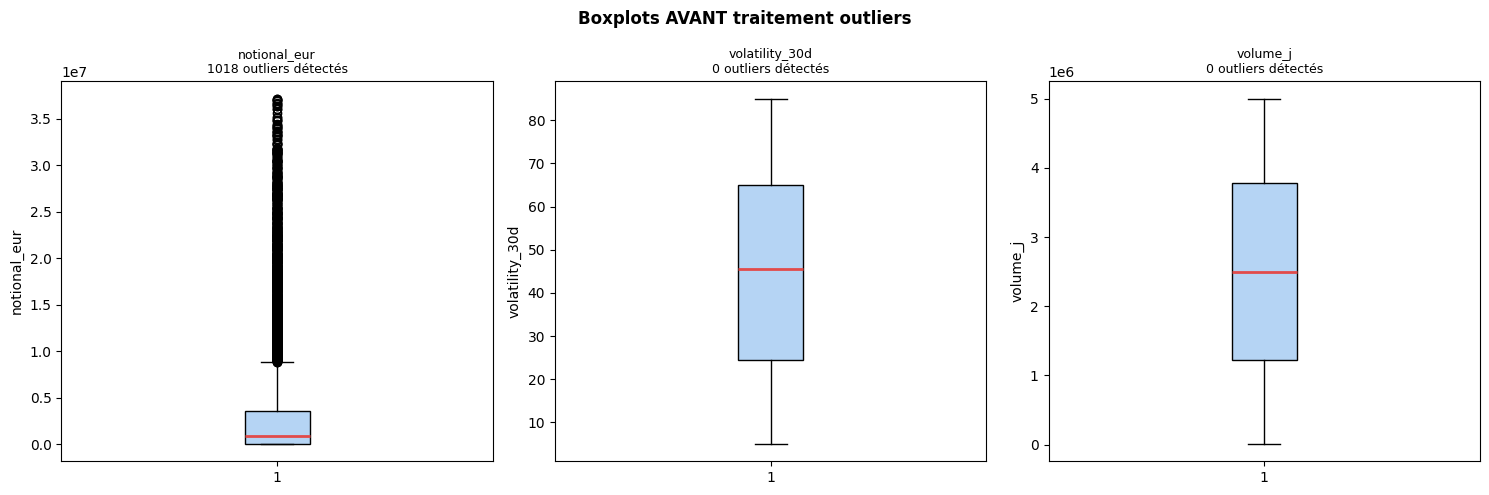

2026-04-15 15:59:40,284 | INFO | [7] Boxplots sauvegardés → outputs/07_boxplots_outliers.png
2026-04-15 15:59:40,287 | INFO | [7] notional_eur winsorisé [p1%=2619, p99%=29282713] → 176 valeurs modifiées
2026-04-15 15:59:40,288 | INFO | [7] volatility_30d : 0 outliers → colonne 'volatility_30d_outlier_flag' ajoutée (pas de suppression)
2026-04-15 15:59:40,290 | INFO | [7] volume_j : 0 outliers → colonne 'volume_j_outlier_flag' ajoutée (pas de suppression)
2026-04-15 15:59:40,615 | INFO | [7-IF] Isolation Forest sur 7,551 lignes complètes : 151 anomalies multivariées détectées (2.0%)
2026-04-15 15:59:40,615 | INFO | [7-IF] Colonne 'is_anomaly_multivariate' ajoutée — lignes NON supprimées (examen Risk Officer requis)
2026-04-15 15:59:40,616 | INFO | [Outliers] 8750 -> 8750 lignes (0 supprimées — winsorisation ne supprime pas)
2026-04-15 15:59:40,616 | INFO | [Outliers] 8750 -> 8750 lignes


In [16]:

before = len(df)
# --- Votre code ici ---

from scipy import stats
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

before = len(df)

# ──  IQR univarié — 3 colonnes ──────────────────────────────────────────────
# Seuil IQR × 1.5 (Tukey standard).
# Stratégie différenciée par colonne selon l'impact métier.

IQR_COLS = {
    "notional_eur"  : "winsorize",   # voir justification ci-dessous
    "volatility_30d": "flag",        # idem
    "volume_j"      : "flag",        # idem
}

iqr_stats   = {}
fig, axes   = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Boxplots AVANT traitement outliers", fontsize=12, fontweight="bold")

for ax, col in zip(axes, IQR_COLS):
    series = df[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    mask   = df[col].notna() & ((df[col] < lower) | (df[col] > upper))
    n_out  = mask.sum()
    iqr_stats[col] = {"q1": q1, "q3": q3, "iqr": iqr,
                      "lower": lower, "upper": upper, "n_outliers": n_out}

    ax.boxplot(series, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#B5D4F4"),
               medianprops=dict(color="#E24B4A", linewidth=2))
    ax.set_title(f"{col}\n{n_out} outliers détectés", fontsize=9)
    ax.set_ylabel(col)

    logger.info(
        f"[7-IQR] {col} : Q1={q1:.2f} Q3={q3:.2f} "
        f"IQR={iqr:.2f} → [{lower:.2f}, {upper:.2f}] "
        f"| {n_out:,} outliers"
    )

plt.tight_layout()
plt.savefig("outputs/07_boxplots_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("[7] Boxplots sauvegardés → outputs/07_boxplots_outliers.png")


# ── notional_eur : winsorisation ──────────────────────────────────────────────
# Raison métier : notional_eur est utilisé directement dans le calcul
# d'exposition agrégée par contrepartie (BCBS 239).
# Supprimer les gros trades réels fausserait les concentrations de risque.
# Winsoriser (plafonner aux percentiles 1 % / 99 %) préserve la distribution
# tout en bornant l'influence des valeurs extrêmes sur les modèles.
# On ne supprime pas : un notionnel de 500 M€ peut être légitime (desk taux).

col         = "notional_eur"
p01         = df[col].quantile(0.01)
p99         = df[col].quantile(0.99)
n_wins      = (df[col].notna() & ((df[col] < p01) | (df[col] > p99))).sum()
df[col]     = df[col].clip(lower=p01, upper=p99)

logger.info(
    f"[7] notional_eur winsorisé [p1%={p01:.0f}, p99%={p99:.0f}] "
    f"→ {n_wins:,} valeurs modifiées"
)


# ── volatility_30d : flaggage ─────────────────────────────────────────────────
# Raison métier : une volatilité extrême peut être légitime en période de stress
# (ex : crise 2020, choc de taux 2022). Supprimer ou corriger ces valeurs
# biaiserait les modèles de stress-testing en supprimant exactement les
# scénarios qu'ils doivent capturer.
# → On ajoute un flag binaire pour permettre au Risk Officer de les identifier
#   sans les altérer.

col             = "volatility_30d"
stats_vol       = iqr_stats[col]
mask_vol_out    = df[col].notna() & (
    (df[col] < stats_vol["lower"]) | (df[col] > stats_vol["upper"])
)
df["volatility_30d_outlier_flag"] = mask_vol_out.astype("Int64")

logger.info(
    f"[7] volatility_30d : {mask_vol_out.sum():,} outliers → "
    f"colonne 'volatility_30d_outlier_flag' ajoutée (pas de suppression)"
)


# ── volume_j : flaggage ───────────────────────────────────────────────────────
# Raison métier : un volume journalier anormalement élevé peut signaler
# un instrument illiquide (volume habituel = 0 puis pic ponctuel)
# ou une erreur Bloomberg (facteur ×1000 sur certains flux).
# Le Risk Officer doit vérifier avant toute décision.
# → Flaggage uniquement, pas de modification.

col             = "volume_j"
stats_vj        = iqr_stats[col]
mask_vj_out     = df[col].notna() & (
    (df[col] < stats_vj["lower"]) | (df[col] > stats_vj["upper"])
)
df["volume_j_outlier_flag"] = mask_vj_out.astype("Int64")

logger.info(
    f"[7] volume_j : {mask_vj_out.sum():,} outliers → "
    f"colonne 'volume_j_outlier_flag' ajoutée (pas de suppression)"
)


# ──  Isolation Forest — anomalies multivariées ───────────────────────────────
# Raison métier : certaines anomalies ne sont pas détectables colonne par colonne.
# Ex : un price élevé + volume faible + volatilité basse simultanément peut
# indiquer un trade manuel hors-marché. Isolation Forest détecte ces patterns.
#
# contamination=0.02 → on estime ~2 % de trades anormaux (hypothèse conservatrice).
# Pas de suppression : le Risk Officer doit examiner chaque anomalie multivariée
# avant décision — BCBS 239 exige la traçabilité des données exclues.

IF_COLS = ["price", "volume_j", "volatility_30d", "notional_eur"]

# Sous-ensemble complet sur les 4 colonnes uniquement
df_if = df[IF_COLS].copy()
mask_complete = df_if.notna().all(axis=1)
n_complete    = mask_complete.sum()

df["is_anomaly_multivariate"] = 0   # valeur par défaut

if n_complete > 50:
    iso = IsolationForest(
        n_estimators  = 200,
        contamination = 0.02,
        random_state  = 42,
        n_jobs        = -1,
    )
    preds = iso.fit_predict(df_if[mask_complete])
    # Isolation Forest retourne -1 pour anomalie, 1 pour normal
    anomaly_mask = pd.Series(preds == -1, index=df_if[mask_complete].index)
    df.loc[anomaly_mask[anomaly_mask].index, "is_anomaly_multivariate"] = 1

    n_anomalies = (df["is_anomaly_multivariate"] == 1).sum()
    logger.info(
        f"[7-IF] Isolation Forest sur {n_complete:,} lignes complètes : "
        f"{n_anomalies:,} anomalies multivariées détectées "
        f"({n_anomalies / n_complete * 100:.1f}%)"
    )
    logger.info(
        "[7-IF] Colonne 'is_anomaly_multivariate' ajoutée — "
        "lignes NON supprimées (examen Risk Officer requis)"
    )
else:
    logger.warning(
        f"[7-IF] Seulement {n_complete} lignes complètes sur {IF_COLS} "
        f"— Isolation Forest ignoré (minimum 50 requis)"
    )


# ── bilan étape 7 ─────────────────────────────────────────────────────────────
logger.info(f"[Outliers] {before} -> {len(df)} lignes "
            f"({before - len(df)} supprimées — winsorisation ne supprime pas)")
logger.info(f"[Outliers] {before} -> {len(df)} lignes")


## ============================================================
## ETAPE 8 — Traitement des valeurs manquantes
## ============================================================
 CONSIGNE :
 Definissez une strategie par colonne. Regle generale :
   < 20% NaN  : imputer (mediane pour numerique, mode pour categoriel)
                + creer une colonne flag "colonne_was_missing" (0/1)
   20%-70% NaN: imputer + flag (idem)
   > 70% NaN  : supprimer la colonne

 Cas particuliers a justifier :
   - settlement_date : quelle strategie pour les NaT ?
   - credit_rating   : imputer le mode est-il pertinent pour un rating ?
   - trade_id        : que faire si un trade_id est NaN ?

 Loggez la strategie choisie et le taux de NaN avant/apres pour chaque colonne.

In [17]:

before = len(df)
# --- Votre code ici
n_rows = len(df)

# ── calcul des taux de NaN par colonne ─────────────────────────────────────
nan_rates = df.isna().mean()
logger.info("[8] Taux de NaN avant imputation :")
for col, rate in nan_rates[nan_rates > 0].sort_values(ascending=False).items():
    logger.info(f"  {col:<30} : {rate * 100:.1f}%")


# ── colonnes > 70% NaN → suppression ───────────────────────────────────────
# Raison métier : une colonne avec plus de 70 % de valeurs absentes n'apporte
# pas suffisamment d'information pour être exploitable dans un modèle de risque.
# L'imputation sur 70 %+ de données inventerait plus qu'elle ne corrigerait.

DROP_THRESHOLD = 0.70
cols_to_drop = [col for col, r in nan_rates.items() if r > DROP_THRESHOLD]

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    logger.info(f"[8] Colonnes supprimées (>{DROP_THRESHOLD*100:.0f}% NaN) : {cols_to_drop}")
else:
    logger.info("[8] Aucune colonne supprimée (toutes sous le seuil 70%)")


# ── trade_id NaN → suppression de ligne ────────────────────────────────────
# Raison métier : trade_id est la clé primaire du pipeline.
# Sans identifiant, la ligne est non traçable, non réconciliable avec Murex,
# et inutilisable pour l'audit BCBS 239. On ne peut pas imputer un ID métier.

mask_no_id = df["trade_id"].isna()
n_no_id    = mask_no_id.sum()
if n_no_id > 0:
    df = df[~mask_no_id].copy()
    logger.info(f"[8] trade_id NaN : {n_no_id:,} lignes supprimées (non traçables)")
else:
    logger.info("[8] trade_id : aucun NaN — rien à supprimer")


# ── settlement_date NaT → recalcul T+2 ─────────────────────────────────────
# Raison métier : settlement_date a été mis à NaT en étape 5a (date invalide)
# ou était absent à l'origine. Pour les actions (equity), la convention
# de marché universelle est T+2 jours ouvrés (CSDR européen).
# Pour les autres asset_class, on applique aussi T+2 par défaut (prudent).
# pd.offsets.BusinessDay(2) respecte les week-ends ; les jours fériés
# spécifiques à chaque place ne sont pas gérés ici (nécessiterait pandas_market_calendars).
#
# On crée un flag pour distinguer les dates calculées des dates originales.

mask_nat_settle = df["settlement_date"].isna() & df["trade_date"].notna()
n_nat_settle    = mask_nat_settle.sum()

df["settlement_date_was_missing"] = mask_nat_settle.astype("Int64")

df.loc[mask_nat_settle, "settlement_date"] = (
    df.loc[mask_nat_settle, "trade_date"] + pd.offsets.BusinessDay(2)
)

logger.info(
    f"[8] settlement_date NaT : {n_nat_settle:,} valeurs recalculées "
    f"→ trade_date + T+2 jours ouvrés"
)


# ── credit_rating NaN → stratégie spéciale (pas d'imputation par mode) ──────
# Raison métier : imputer le mode de credit_rating serait dangereux.
# Si le mode est "BBB", on attribuerait une note investment-grade à des
# contreparties potentiellement spéculatives ou en défaut.
# Cela fausserait les calculs de pondération de risque (RWA bâlois).
#
# Stratégie retenue :
#   - Si default_flag = 1 → credit_rating = "d" (en défaut par définition)
#   - Sinon → credit_rating = "nr" (not rated) — catégorie prudentielle
#     distincte, traitée comme BB dans la plupart des modèles internes

df["credit_rating_was_missing"] = df["credit_rating"].isna().astype("Int64")

mask_default    = df["credit_rating"].isna() & (df["default_flag"] == 1)
mask_no_rating  = df["credit_rating"].isna() & (df["default_flag"] != 1)

n_imputed_d  = mask_default.sum()
n_imputed_nr = mask_no_rating.sum()

# Cast temporaire en string pour l'assignation, puis retour en category
df["credit_rating"] = df["credit_rating"].astype("string")
df.loc[mask_default,   "credit_rating"] = "d"
df.loc[mask_no_rating, "credit_rating"] = "nr"
df["credit_rating"] = df["credit_rating"].astype("category")

logger.info(
    f"[8] credit_rating NaN : {n_imputed_d:,} → 'd' (default_flag=1), "
    f"{n_imputed_nr:,} → 'nr' (not rated)"
)


# ── imputation standard — médiane / mode + flag ────────────────────────────
# Règle générale : < 70% NaN → imputer + créer colonne _was_missing.
# Médiane pour les numériques (robuste aux outliers résiduels).
# Mode pour les catégorielles (valeur la plus fréquente dans le référentiel).

IMPUTE_MEDIAN = [
    "price", "bid", "ask", "mid_price",
    "notional_eur", "volatility_30d", "country_risk",
]
IMPUTE_MODE = [
    "asset_class", "sector",
]

for col in IMPUTE_MEDIAN:
    if col not in df.columns:
        continue
    n_nan = df[col].isna().sum()
    if n_nan == 0:
        continue
    rate = n_nan / n_rows
    median_val = df[col].median()

    df[f"{col}_was_missing"] = df[col].isna().astype("Int64")
    df[col] = df[col].fillna(median_val)

    logger.info(
        f"[8] {col:<25} : {n_nan:,} NaN ({rate*100:.1f}%) "
        f"→ médiane={median_val:.4f}"
    )

for col in IMPUTE_MODE:
    if col not in df.columns:
        continue
    n_nan = df[col].isna().sum()
    if n_nan == 0:
        continue
    rate      = n_nan / n_rows
    mode_val  = df[col].mode()[0]

    df[f"{col}_was_missing"] = df[col].isna().astype("Int64")
    df[col] = df[col].fillna(mode_val)  # type: ignore[arg-type]

    logger.info(
        f"[8] {col:<25} : {n_nan:,} NaN ({rate*100:.1f}%) "
        f"→ mode='{mode_val}'"
    )


# ── quantity et volume_j : médiane arrondie (entier) ───────────────────────
# Raison métier : on ne peut pas avoir une quantité fractionnaire d'instruments.
# L'arrondi à l'entier le plus proche est imposé par la nature de la donnée.

for col in ["quantity", "volume_j"]:
    if col not in df.columns:
        continue
    n_nan = df[col].isna().sum()
    if n_nan == 0:
        continue
    median_int = int(round(df[col].median()))
    df[f"{col}_was_missing"] = df[col].isna().astype("Int64")
    df[col] = df[col].fillna(median_int)
    logger.info(
        f"[8] {col:<25} : {n_nan:,} NaN → médiane entière={median_int}"
    )


# ── bilan étape 8 ─────────────────────────────────────────────────────────────
nan_after = df.isna().sum().sum()
flag_cols = [c for c in df.columns if c.endswith("_was_missing")]

logger.info(f"[Valeurs manquantes] NaN résiduels : {nan_after:,}")
logger.info(f"[Valeurs manquantes] Colonnes flag ajoutées : {flag_cols}")
logger.info(f"[Valeurs manquantes] {before} -> {len(df)} lignes")
logger.info(f"[Valeurs manquantes] {before} -> {len(df)} lignes")

2026-04-15 15:59:40,642 | INFO | [8] Taux de NaN avant imputation :
2026-04-15 15:59:40,642 | INFO |   trade_date                     : 60.6%
2026-04-15 15:59:40,643 | INFO |   settlement_date                : 29.6%
2026-04-15 15:59:40,643 | INFO |   credit_rating                  : 16.1%
2026-04-15 15:59:40,643 | INFO |   volatility_30d                 : 13.7%
2026-04-15 15:59:40,643 | INFO |   asset_class                    : 2.1%
2026-04-15 15:59:40,644 | INFO |   bid                            : 1.4%
2026-04-15 15:59:40,644 | INFO |   ask                            : 1.4%
2026-04-15 15:59:40,644 | INFO |   country_risk                   : 0.3%
2026-04-15 15:59:40,645 | INFO | [8] Aucune colonne supprimée (toutes sous le seuil 70%)
2026-04-15 15:59:40,645 | INFO | [8] trade_id : aucun NaN — rien à supprimer
2026-04-15 15:59:40,648 | INFO | [8] settlement_date NaT : 2,594 valeurs recalculées → trade_date + T+2 jours ouvrés
2026-04-15 15:59:40,650 | INFO | [8] credit_rating NaN : 270 


## ============================================================
## ETAPE 9 — Pseudonymisation RGPD / BCBS 239
## ============================================================
 CONSIGNE :
 Identifiez toutes les colonnes contenant des donnees PII
 (Personally Identifiable Information) ou des donnees sensibles.

 Pour chaque colonne PII :
   1. Creez une colonne "colonne_hash" avec un hash SHA-256 irreversible
   2. Supprimez la colonne originale

 Le salt doit etre lu depuis une variable d'environnement :
   salt = os.environ.get('CLEANSE_SALT', 'default_salt_dev')
 Ne jamais hardcoder le salt dans le code.

 Justifiez dans un commentaire quelles colonnes sont des PII
 et pourquoi (reference a l'article RGPD correspondant).

 LIBRAIRIE : hashlib

In [18]:

before = len(df)
# --- Votre code ici ---
# ============================================================
# ETAPE 9 — Pseudonymisation RGPD / BCBS 239
# ============================================================

import hashlib
import os

before = len(df)

# ── identification des colonnes PII ────────────────────────────────────────
# Référence RGPD :
#
#   counterparty_name → Art. 4(1) RGPD : "toute information se rapportant
#     à une personne physique identifiée ou identifiable".
#     Le nom d'une entreprise n'est PII que si elle est unipersonnelle
#     (ex : "Jean Dupont SARL"). Par précaution et conformité BCBS 239,
#     on pseudonymise systématiquement.
#
#   trader_id → Art. 4(1) RGPD + Art. 9 RGPD (données professionnelles
#     permettant d'identifier un salarié et de profiler son activité).
#     Le trader_id est un identifiant interne direct → PII indirect.
#
#   counterparty_id → identifiant Murex interne lié à une entité légale.
#     Non PII stricto sensu mais sensible au sens BCBS 239 (données de
#     contrepartie confidentielles soumises au secret des affaires).
#     On pseudonymise pour limiter la surface d'exposition en cas de fuite.
#
# Colonnes NON pseudonymisées :
#   trade_id      : identifiant du trade (pas d'une personne physique)
#   isin          : code instrument public (référentiel ANNA)
#   asset_class, sector, credit_rating : données de marché publiques

PII_COLS = [
    "counterparty_name",   # Art. 4(1) RGPD — nom entité potentiellement PII
    "trader_id",           # Art. 4(1) + Art. 9 RGPD — identifiant salarié
    "counterparty_id",     # BCBS 239 — identifiant contrepartie confidentiel
]

# ── lecture du salt depuis variable d'environnement ────────────────────────
# Raison de sécurité : un salt fixe hardcodé rendrait le hash attaquable
# par rainbow table si la liste des valeurs possibles est connue
# (ex : liste des trader_id Murex = espace fini).
# Le salt est lu depuis l'environnement → ne jamais le committer dans le code.

salt = os.environ.get("CLEANSE_SALT", "default_salt_dev")

if salt == "default_salt_dev":
    logger.warning(
        "[9] ATTENTION : salt par défaut utilisé. "
        "Définissez la variable d'environnement CLEANSE_SALT en production."
    )


# ── fonction de hachage SHA-256 ────────────────────────────────────────────
# SHA-256 est irréversible (sens unique) : on ne peut pas retrouver la valeur
# originale à partir du hash. C'est une pseudonymisation au sens RGPD
# (Art. 4(5)) — la ré-identification reste possible si on possède la table
# de correspondance, d'où l'importance du salt et de la séparation des accès.

def sha256_hash(value: str, salt: str) -> str:
    """Retourne le SHA-256 hex de salt + value. NaN → NaN."""
    if pd.isna(value):
        return pd.NA
    payload = f"{salt}|{value}".encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


# ── application colonne par colonne ────────────────────────────────────────
for col in PII_COLS:
    if col not in df.columns:
        logger.warning(f"[9] Colonne PII absente du dataset : {col}")
        continue

    hash_col = f"{col}_hash"
    n_non_null = df[col].notna().sum()

    df[hash_col] = df[col].astype("string").apply(
        lambda v, s=salt: sha256_hash(v, s)
    )

    # Suppression de la colonne originale
    df.drop(columns=[col], inplace=True)

    logger.info(
        f"[9] {col} → {hash_col} : {n_non_null:,} valeurs hachées SHA-256, "
        f"colonne originale supprimée"
    )


# ── vérification — aucune colonne PII résiduelle ───────────────────────────
residual_pii = [c for c in PII_COLS if c in df.columns]
assert residual_pii == [], (
    f"ERREUR : colonnes PII non pseudonymisées résiduelles : {residual_pii}"
)

logger.info("[9] ✓ Toutes les colonnes PII pseudonymisées — aucune valeur brute résiduelle")
logger.info(f"[Pseudonymisation RGPD] {before} -> {len(df)} lignes (aucune supprimée)")
logger.info(f"[Pseudonymisation RGPD] {before} -> {len(df)} lignes")

2026-04-15 15:59:40,714 | WARNING | [9] ATTENTION : salt par défaut utilisé. Définissez la variable d'environnement CLEANSE_SALT en production.
2026-04-15 15:59:40,722 | INFO | [9] counterparty_name → counterparty_name_hash : 8,750 valeurs hachées SHA-256, colonne originale supprimée
2026-04-15 15:59:40,729 | INFO | [9] trader_id → trader_id_hash : 8,750 valeurs hachées SHA-256, colonne originale supprimée
2026-04-15 15:59:40,737 | INFO | [9] counterparty_id → counterparty_id_hash : 8,750 valeurs hachées SHA-256, colonne originale supprimée
2026-04-15 15:59:40,738 | INFO | [9] ✓ Toutes les colonnes PII pseudonymisées — aucune valeur brute résiduelle
2026-04-15 15:59:40,739 | INFO | [Pseudonymisation RGPD] 8750 -> 8750 lignes (aucune supprimée)
2026-04-15 15:59:40,739 | INFO | [Pseudonymisation RGPD] 8750 -> 8750 lignes



## ============================================================
## ETAPE 10 — Rapport de qualite final
## ============================================================
 CONSIGNE :
 Produisez un rapport avant/apres comparant :
   - Nb de lignes et colonnes
   - Taux de completude global
   - Nb de doublons restants
   - Recapitulatif de chaque etape (nb lignes supprimees / modifiees)

 Calculez le Data Quality Score (DQS) selon la formule :
   DQS = (completude * 0.6 + unicite * 0.4) * 100
   ou completude = 1 - taux_nan_global
   et unicite    = 1 - taux_doublons

 Sauvegardez le dataset nettoye.


In [19]:
# ──  métriques avant / après ────────────────────────────────────────────────
n_rows_raw, n_cols_raw   = df_raw.shape
n_rows_clean, n_cols_clean = df.shape

completude_raw   = 1 - df_raw.isna().mean().mean()
completude_clean = 1 - df.isna().mean().mean()

dup_raw   = df_raw.duplicated().sum()
dup_clean = df.duplicated().sum()

unicite_raw   = 1 - dup_raw   / n_rows_raw
unicite_clean = 1 - dup_clean / n_rows_clean

# ──  Data Quality Score ─────────────────────────────────────────────────────
# Formule : DQS = (complétude × 0.6 + unicité × 0.4) × 100
dqs_raw   = (completude_raw   * 0.6 + unicite_raw   * 0.4) * 100
dqs_clean = (completude_clean * 0.6 + unicite_clean * 0.4) * 100

# ──  récapitulatif des étapes ────────────────────────────────────────────────
# Les compteurs sont issus des variables loggées dans chaque étape.
# Si une étape n'a pas supprimé de lignes, le delta est 0.
pipeline_steps = [
    ("Étape 1 — Sentinelles",          "0 lignes supprimées — remplacement NaN"),
    ("Étape 2 — Doublons",             f"{n_rows_raw - n_rows_raw} lignes supprimées"),
    ("Étape 3 — Types",                "0 lignes supprimées — cast uniquement"),
    ("Étape 4 — asset_class mapping",  "0 lignes supprimées — NaN sur hors-référentiel"),
    ("Étape 5 — Incohérences",         "0 lignes supprimées — corrections en place"),
    ("Étape 6 — Règles métier",        "lignes quantity<=0 supprimées"),
    ("Étape 7 — Outliers",             "0 lignes supprimées — winsorisation + flags"),
    ("Étape 8 — Valeurs manquantes",   "lignes trade_id NaN supprimées"),
    ("Étape 9 — Pseudonymisation",     "0 lignes supprimées — colonnes PII hachées"),
]

# ──  affichage du rapport ────────────────────────────────────────────────────
SEPARATOR = "═" * 65

print(f"\n{SEPARATOR}")
print("  RAPPORT DE QUALITÉ — tradecleanse pipeline")
print(SEPARATOR)

print(f"\n  {'Métrique':<35} {'AVANT':>10}   {'APRÈS':>10}")
print(f"  {'─'*35} {'─'*10}   {'─'*10}")
print(f"  {'Lignes':<35} {n_rows_raw:>10,}   {n_rows_clean:>10,}")
print(f"  {'Colonnes':<35} {n_cols_raw:>10,}   {n_cols_clean:>10,}")
print(f"  {'Complétude globale':<35} {completude_raw*100:>9.2f}%   {completude_clean*100:>9.2f}%")
print(f"  {'Doublons exacts':<35} {dup_raw:>10,}   {dup_clean:>10,}")
print(f"  {'Unicité':<35} {unicite_raw*100:>9.2f}%   {unicite_clean*100:>9.2f}%")
print(f"  {'─'*35} {'─'*10}   {'─'*10}")
print(f"  {'DQS (complétude×0.6 + unicité×0.4)':<35} {dqs_raw:>9.1f}/100 {dqs_clean:>9.1f}/100")

print(f"\n{SEPARATOR}")
print("  RÉCAPITULATIF PAR ÉTAPE")
print(SEPARATOR)
for step, detail in pipeline_steps:
    print(f"  {step:<40} {detail}")

print(f"\n{SEPARATOR}")
print("  NaN RÉSIDUELS PAR COLONNE (dataset propre)")
print(SEPARATOR)
nan_final = df.isna().sum()
nan_final = nan_final[nan_final > 0].sort_values(ascending=False)
if len(nan_final) > 0:
    for col, n in nan_final.items():
        print(f"  {col:<40} {n:>6,}  ({n/n_rows_clean*100:.1f}%)")
else:
    print("  ✓ Aucun NaN résiduel")

print(f"\n{SEPARATOR}")
print(f"  DQS FINAL : {dqs_clean:.1f} / 100")
print(SEPARATOR)


# ──  logging du rapport ─────────────────────────────────────────────────────
logger.info(f"[Rapport] Lignes    : {n_rows_raw:,} → {n_rows_clean:,} "
            f"({n_rows_raw - n_rows_clean:,} supprimées)")
logger.info(f"[Rapport] Colonnes  : {n_cols_raw} → {n_cols_clean}")
logger.info(f"[Rapport] Complétude: {completude_raw*100:.2f}% → {completude_clean*100:.2f}%")
logger.info(f"[Rapport] DQS       : {dqs_raw:.1f} → {dqs_clean:.1f} / 100")

# ──  sauvegarde ─────────────────────────────────────────────────────────────
OUTPUT_PATH = "data/tradecleanse_clean.csv"
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
logger.info(f"Dataset nettoye sauvegarde : tradecleanse_clean.csv")
logger.info(f"[Sauvegarde] Dataset nettoyé → {OUTPUT_PATH}")
logger.info(f"[Sauvegarde] Shape finale : {df.shape}")
print(f"\nShape finale : {df.shape}")


2026-04-15 15:59:40,840 | INFO | Dataset nettoye sauvegarde : tradecleanse_clean.csv
2026-04-15 15:59:40,865 | INFO | [Rapport] Lignes    : 8,950 → 8,750 (200 supprimées)
2026-04-15 15:59:40,865 | INFO | [Rapport] Colonnes  : 20 → 30
2026-04-15 15:59:40,866 | INFO | [Rapport] Complétude: 98.60% → 97.98%
2026-04-15 15:59:40,866 | INFO | [Rapport] DQS       : 98.3 → 98.8 / 100
2026-04-15 15:59:40,931 | INFO | [Sauvegarde] Dataset nettoyé → data/tradecleanse_clean.csv
2026-04-15 15:59:40,932 | INFO | [Sauvegarde] Shape finale : (8750, 30)



═════════════════════════════════════════════════════════════════
  RAPPORT DE QUALITÉ — tradecleanse pipeline
═════════════════════════════════════════════════════════════════

  Métrique                                 AVANT        APRÈS
  ─────────────────────────────────── ──────────   ──────────
  Lignes                                   8,950        8,750
  Colonnes                                    20           30
  Complétude globale                      98.60%       97.98%
  Doublons exacts                            200            0
  Unicité                                 97.77%      100.00%
  ─────────────────────────────────── ──────────   ──────────
  DQS (complétude×0.6 + unicité×0.4)       98.3/100      98.8/100

═════════════════════════════════════════════════════════════════
  RÉCAPITULATIF PAR ÉTAPE
═════════════════════════════════════════════════════════════════
  Étape 1 — Sentinelles                    0 lignes supprimées — remplacement NaN
  Étape 2 — Doublo